# 2-2. 데이터 생성 방법

# 수업 내용
1. 소량의 Text 데이터 생성하기
2. 대량의 Text 데이터 생성 방법 이해
    - 소형 모델로 데이터 생성
    - LLM as a judge로 데이터 필터링
3. 데이터 생성 방법 이해
    - 데이터 증강
    - 합성 데이터
4. Image 데이터 증강


# 1. 소량의 Text 데이터 생성 방법
- AI로 데이터를 생성하는 가장 쉬운 방법이 있습니다.
  - LLM (대규모 언어모델)에게 데이터를 생성해달라고 하는겁니다.

### 데이터 생성 실습
- AI에게 예시를 주고, 새로운 데이터를 만들어봅시다.

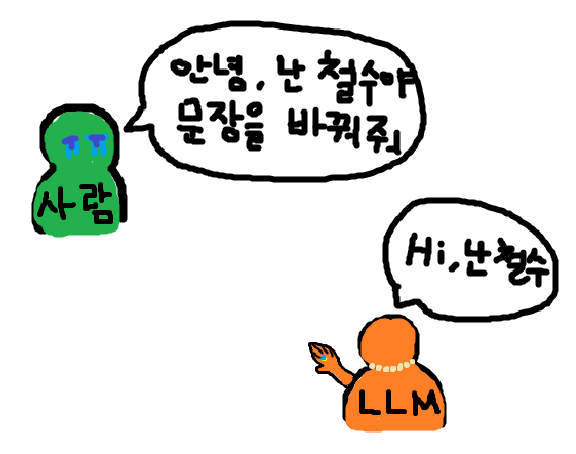

- 실습을 해봅시다.
- ChatGPT를 켜고, 다음 프롬프트를 입력해주세요.
```
원본 데이터를 기반으로 새로운 데이터들을 만들어줘
- 같은 의미를 가지고 있지만, 다양한 표현으로 바꾸어줘
- 사람이 이해할 수 있는 문장이어야 해
- 원본 데이터 : "안녕, 난 철수야. KFC를 좋아하지"

아래 예시를 보고, 같은 Format으로 만들어줘
{
  "name": "철수",
  "age": 30,
  "height": 185,
  "messages": [
    {
      "직업": "아나운서",
      "인사말": "안녕하십니까. 철수입니다. 저는 KFC를 참 좋아하는데요."
    },
    {
      "직업": "리포터",
      "인사말": "안녕하세요 여러분. 철수예요. 저는 KFC를 사랑합니다. 여러분도 사랑해요."
    },
    {
      ...
    }
  ]
}

총 20개 문장이 되도록 만들어줘.
최종 결과파일은 data.json 파일로 다운로드 받을 수 있게 해줘
```

- 잘 만들어졌습니다.
  - json 포맷으로 만들어졌지만, 생성한 내용만 적으면 다음과 같습니다.

```
안녕하십니까. 철수입니다. 저는 KFC를 참 좋아하는데요.
안녕하세요 여러분. 철수예요. 저는 KFC를 사랑합니다. 여러분도 사랑해요.
안녕하세요, 배우 철수입니다. 사실 전 KFC보다는 치킨버거를 더 좋아하죠.
안녕하세요. 요리사 철수입니다. KFC의 양념 치킨은 정말 훌륭하다고 생각해요.
안녕! 나는 유튜버 철수야. 오늘은 KFC 신메뉴 리뷰를 하려고 해.
안녕하세요, 기자 철수입니다. 오늘은 KFC의 인기 비결에 대해 알아보겠습니다.
안녕하세요, 디자이너 철수입니다. KFC의 로고 컬러는 언제 봐도 강렬하죠.
여러분 안녕하세요. 저는 선생님 철수예요. 수업 후엔 KFC 치킨을 즐긴답니다.
안녕, 나 철수야. 공부 끝나면 KFC 치킨으로 스트레스 풀어!
안녕하세요, 개발자 철수입니다. 코딩하다 보면 KFC 생각이 간절하죠.
안녕하세요, 의사 철수입니다. 가끔은 KFC로 피로를 풀곤 해요.
안녕하세요, 간호사 철수입니다. 야근 끝나고 먹는 KFC가 최고예요.
안녕하세요, 선수 철수입니다. 운동 후에는 KFC 치킨이 딱이죠!
안녕하세요, 작가 철수입니다. 글을 쓰다 보면 KFC 향이 떠오르네요.
안녕하세요, 화가 철수입니다. KFC의 빨간색은 제게 영감을 줍니다.
안녕하세요! 가수 철수입니다. 무대 전엔 꼭 KFC로 에너지 충전!
안녕하세요, 배달하는 철수입니다. 쉬는 날엔 저도 KFC를 시켜 먹어요.
충성! 군인 철수입니다. 휴가 나오면 제일 먼저 KFC를 찾습니다.
```

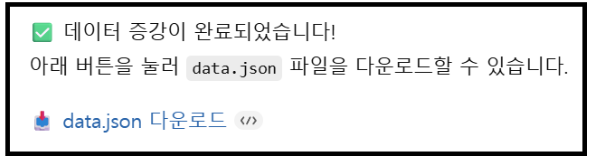

- 쉽죠? 소량 데이터는 위와 같이 LLM을 사용해서 만들면 됩니다.
  - 그럼 대형 데이터는 어떻게 만들면 될까요?

### [경고] ChatGPT에게 **대량의 데이터** 생성을 요청하면 안됩니다!
- 돈이 많이 들수있어요!
- 10MB 용량의 데이터 (약 50,000개 문장)을 만드는데 250만 토큰이 들 수 있습니다.
  - 250만 토큰은 ChatGPT 무료티어 한방에 끝날겁니다.

### 그러면 OpenAI API를 사용하면 되나요?
- 가격을 고려하고 사용하시면 됩니다!
- GPT-4o mini 모델 기준으로, 출력 토큰 25만개 토큰이면 $1.5.. 약 2,000원 정도 나가요.
- 100번 시도하면 20만원!!
- 1000명이 10번씩만 실습해도 2,000만원!!!
  
<br/>

- **용량을 정해서 데이터를 만들어 달라고 하시면 됩니다~.**
  - 데이터 1MB 정도는 GPT에게 시켜도 되겠습니다. (200원 들어요.)

### 그러면, 대량의 데이터는 어떻게 생성하는 좋은 방법은요?
- 쓰는 만큼 요금을 내는, 클라우드 기반의 모델을 사용하지 않습니다.
- 허깅페이스의 모델을 사용해서, 코랩 or 추론서버에서 돌리면 됩니다!

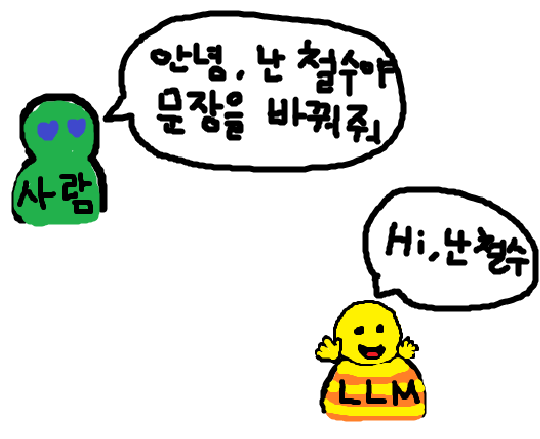

# 2. 대량의 Text 데이터 생성 방법

### 소형 모델 세팅
- 한글이 잘 되는 모델을 준비합니다.
  - Qwen3-0.6B 를 사용하겠습니다. 코랩에서 동작하는 초소형 모델입니다.
  - https://huggingface.co/Qwen/Qwen3-0.6B

- 아래 명령어를 실행해서 transformers 를 최신버전으로 업그레이드 합시다.
  - Default로 설치되어 있는 tranformers 모델은 Qwen3가 동작이 안되었습니다.
  - Qwen3 Model Card에 transfomers 버전이 4.51보다 낮으면 "KeyError: 'qwen3'" 라는 에러가 난다고 합니다.  
  - 한 1분정도 기다리면, Runtime을 다시 시작해야한다고 메세지가 나옵니다. 확인 누르시면 됩니다.

In [1]:
!pip install transformers==4.57.3

- 아래 코드는 Qwen3 모델을 다운로드 및 로드하는 코드입니다.
  - 한 1분 지나면 다운로드가 시작됩니다.
  - 다운로드 용량은 약 1.5G 입니다.

### Windows 가상메모리 늘리기

- 경로
  - 제어판 → 시스템 → 고급 시스템 설정 → 성능 → 설정 → 고급 → 가상 메모리
- 추천 값
  - 초기 크기 : 16384 MB
  - 최대 크기 : 32768 MB

In [3]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 장치 : ", device)

model_name = "Qwen/Qwen3-0.6B"
print("모델 이름 : ", model_name)

# load the tokenizer and the model
tokenizer = AutoTokenizer.from_pretrained(model_name)

# CPU 메모리 많이 사용
# model = AutoModelForCausalLM.from_pretrained(
#     model_name,
#     dtype="auto",
#     device_map="auto"
# )

# GPU 사용
# 1. RTX 5060(Blackwell) 최적화 모델 로드
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.bfloat16,        # RTX 5060은 BF16 연산이 FP16보다 안정적이고 빠릅니다.
    low_cpu_mem_usage=True,
    device_map="auto",                 # accelerate를 사용하여 GPU 메모리에 자동 배치
    attn_implementation="sdpa"         # PyTorch 2.8 내장 가속 어텐션 사용 (Flash Attention 대신 사용 가능)
)

# 2. [선택] 추론 속도 최적화 (PyTorch 2.8 컴파일)
# 텍스트 생성 속도(Tokens per second)를 높이고 싶을 때 추가하세요.
model = torch.compile(model)

사용 장치 :  cuda
모델 이름 :  Qwen/Qwen3-0.6B


- 아래 코드는 추론하는 코드입니다.
  - GPU 수행시 : 1회 추론시 약 3초 소요
  - CPU 수행시 : 1회 추론시 약 12초 소요

In [4]:
prompt = "너의 이름이 뭐니?"

messages = [
    {
        "role": "user",
        "content": prompt
    }
]

# 토큰화
text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=False)
print(text)
# 모델에 입력하기 위해 PyTouch의 Tensor로 변경
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

# 모델 추론
# generated_ids: 출력결과는 인덱싱 이다.
generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=500,
    temperature=0.7,  # 수가 적을수록 확률분포가 날카로워져 같은 문장이 반복됨
    top_p=0.8,        # 수가 커질수록 단어 선택 후보가 더 많아짐
)

# 디코딩 (토큰 ID를 문자로 변환)
output_ids = generated_ids[0][len(model_inputs.input_ids[0]):]
content = tokenizer.decode(output_ids, skip_special_tokens=True)

print(content)

<|im_start|>user
너의 이름이 뭐니?<|im_end|>
<|im_start|>assistant
<think>

</think>


안녕하세요! 저는 "나"입니다. 😊


### 데이터 생성하기

- 프롬프트를 입력하여 Text를 생성해보겠습니다.

In [5]:
prompt = """
원본 데이터를 기반으로 새로운 데이터들을 만들어줘
같은 의미를 가지고 있지만, 다양한 표현으로 바꾸어줘

원본 데이터 : "안녕, 난 철수야. KFC를 좋아하지"
만들고 싶은 데이터 예시는 다음과 같아
1. 안녕하세요, 철수입니다. 오늘은 KFC의 인기 비결에 대해 알아보겠습니다.
2. 안녕~, 철수예요. KFC의 로고 컬러는 언제 봐도 강렬하죠.
3. 여러분 안녕하세요. 저는 철수랍니다. 수업 후엔 KFC 치킨을 즐긴답니다.

새로운 문장 1개로만 대답해줘
"""

messages = [
    {
        "role": "user",
        "content": prompt
    }
]

# 토큰화
text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=False)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

# 모델 추론
generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=500,
    temperature=0.7,  # 수가 적을수록 확률분포가 날카로워져 같은 문장이 반복됨
    top_p=0.8,        # 수가 커질수록 단어 선택 후보가 더 많아짐
)

# 디코딩 (토큰 ID를 문자로 변환)
output_ids = generated_ids[0][len(model_inputs.input_ids[0]):]
content = tokenizer.decode(output_ids, skip_special_tokens=True)

print(content)

안녕하세요, 철수입니다. KFC의 인기 비결은 언제 봐도 강렬합니다.


- 출력되는 소스코드를 편집하면, 5000개 문장도 생성할 수 있을 것 같습니다.
  - for 문을 돌려서, 반복적으로 수행하면 되겠습니다.
  - 한 문장 생성당 Runtime 사용 1초씩 사용됩니다.
    - 5000초가 드니까, 코랩 Runtime 2시간이면 되겠네요 ^^
    - 코랩 대신, 좋은 GPU가 달린 추론 서버를 돌리면, 걱정은 없겠습니다.

### Temperature, Top_p 파라미터 조율

- 아래와 같은 코드가 있었습니다.

``` python
# 모델 추론
generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=500,
    temperature=0.7,  # 수가 적을수록 확률분포가 날카로워져 같은 문장이 반복됨
    top_p=0.8,        # 수가 커질수록 단어 선택 후보가 더 많아짐
)
```

- 추론을 할 때 temperature와 top_p 라는 옵션이 있습니다.
- 이 옵션을 조율하면 답변의 다양성을 더 높일 수 있습니다.
  - 너무 똑같은 대답만 반복할 때이 값을 조율합니다.
  - 대신 너무 다양하면, 말도 안되는 문장을 만들어낼수도 있습니다.

- 아래 그림은 [KFC는 정말 ...] 다음 단어를 선택할 후보를 나타냈습니다.
  - 아래 그림에서는 "맛있다" 가 선택될 확률이 90% 이네요.

-

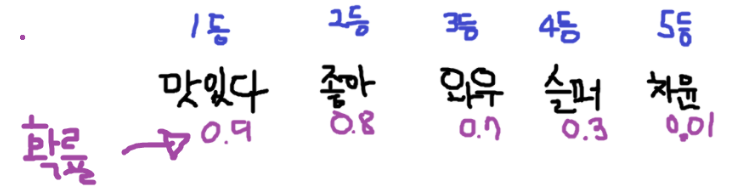

- 먼저 top_p 에 대해 보겠습니다.

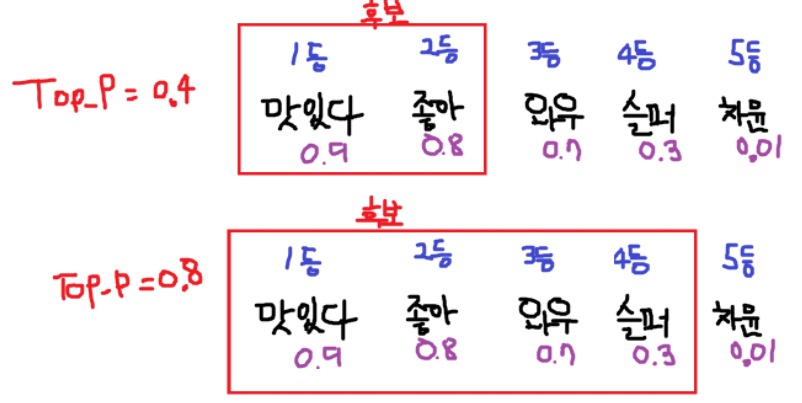

- top_p가 0.8 이면 후보 단어중 상위 80% 를 후보중에 선택하겠다는 의미입니다.
- top_p가 너무 작은 값이면, 창의성이 없는 똑같은 정답만 대답하겠죠?

- 이번엔 temperature 입니다.
- 모든 단어에 대해 logit (점수) 가 존재해요. — 이건 모델이 내부적으로 계산하는 숫자 (확률 이전 단계)
- 이 logit에 대해 logit / temperature 를 해서, 높은 점수는 더 높아지고, 낮은 점수는 더 낮아집니다.
- 그 상태에서 softmax로 확률을 다시 계산합니다.

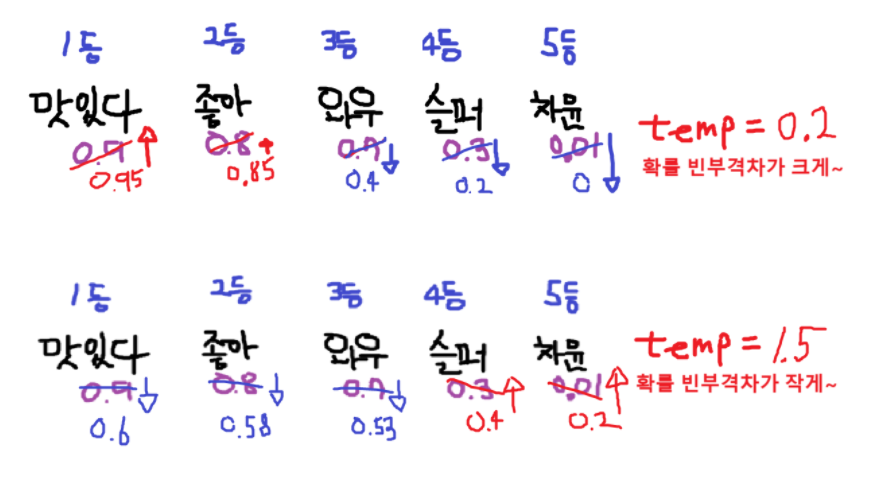


  - temp가 낮으면, 선택 확률의 빈부격차가 심해집니다.
    - 맨날 선택되는 것만 더 잘 선택되어요.
  - temp가 높으면, 선택 확률이 비슷비슷해집니다.
    - 창의성있는 선택이 될 수 있습니다.

- 아래 주석 코드를 바꿔가면서, 여러번 실행해보세요!

In [6]:
prompt = """
원본 데이터를 기반으로 새로운 데이터들을 만들어줘
같은 의미를 가지고 있지만, 다양한 표현으로 바꾸어줘

원본 데이터 : "안녕, 난 철수야. KFC를 좋아하지"
만들고 싶은 데이터 예시는 다음과 같아
1. 안녕하세요, 철수입니다. 오늘은 KFC의 인기 비결에 대해 알아보겠습니다.
2. 안녕~, 철수예요. KFC의 로고 컬러는 언제 봐도 강렬하죠.
3. 여러분 안녕하세요. 저는 철수랍니다. 수업 후엔 KFC 치킨을 즐긴답니다.

새로운 문장 1개로만 대답해줘
"""

messages = [
    {
        "role": "user",
        "content": prompt
    }
]

# 토큰화
text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=False)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

# 10개 문장을 만들자!
for i in range(10):

  # 모델 추론
  generated_ids = model.generate(
      **model_inputs,
      max_new_tokens=500,

      # ==================================
      # 창의성 넘치지만, 생성된 데이터 품질이 낮음
      # temperature=1.8,
      # top_p=0.9,

      # 창의성 없지만, 생성된 데이터 품질이 높음
      # temperature=0.6,
      # top_p=0.5,

      # Qwen3 권장 튜닝값
      temperature=0.7,
      top_p=0.8,
      # ==================================
  )

  # 디코딩 (토큰 ID를 문자로 변환)
  output_ids = generated_ids[0][len(model_inputs.input_ids[0]):]
  content = tokenizer.decode(output_ids, skip_special_tokens=True)

  print(content)

안녕하세요, 철수입니다. KFC의 인기 비결은 무엇인지 알고 싶으니, 수업 후엔 KFC 치킨을 즐길 수 있어요.
안녕하세요, 철수입니다. KFC의 인기 비결은 오늘을 잘 지켜보겠습니다.
안녕하세요, 철수입니다. KFC의 인기 비결은 오늘 가장 높은 관심사입니다.
안녕하세요, 철수입니다. KFC의 인기 비결은 언제 봐도 강렬합니다.
안녕하세요, 철수입니다. KFC의 인기 뉴스를 공유해보겠습니다.
안녕하세요, 철수입니다. KFC의 인기 비결은 언제 봐도 강렬합니다.
안녕하세요, 철수입니다. KFC의 인기 있는 치킨을 즐기고 있어요.
안녕하세요, 철수입니다. KFC의 인기 비결은 오늘을 더욱 즐기고 싶습니다.
안녕하세요, 철수입니다. KFC의 인기 비결은 오늘에 따라 알아보겠습니다.
안녕하세요, 철수입니다. KFC의 인기 레벨은 오늘 매우 높아요.


- 다음과 같은 상황이 될때, 두 파라미터를 조율하시면 됩니다.
  - AI가 만든 데이터가 똑같은 값이 반복적일때 : 창의성을 높이기 위해 Temp, top_p 둘다 UP
  - AI가 만든 데이터가 말도 안되는 값을 자주 만들때 : 정확도를 높이기 위해 Temp, top_p 둘다 Down

### 부정확한 데이터 필터링하기
- Temperature와 Top_p를 적절히 조율 했지만, 부정확한 데이터가 간헐적으로 나옵니다.
- 이런 데이터를 필터링하는 방법도 있겠지만 이 역시 AI가 하면 되겠죠?
- 다음 내용에서 AI를 이용해서 품질이 낮은 데이터를 필터링하는 방법을 소개합니다.

# 3. LLM as a judge로 품질 낮은 데이터 필터링하기

- LLM as a judge는 AI 모델이 만들어낸 결과를, 더 높은 수준의 AI 모델이 평가하는 것을 뜻합니다.
- 오해하지마세요.
  - LLM as a judge는 주로 **벤치마크 용도로 주로 사용됩니다.**
  - 그런데 지금은 데이터가 잘 만들어졌는지, 다른 AI 모델로 평가시킬려고 하는 겁니다.
    - 오해하지마세요. LLM as a judge의 주 목적은 벤치마크용입니다.
  

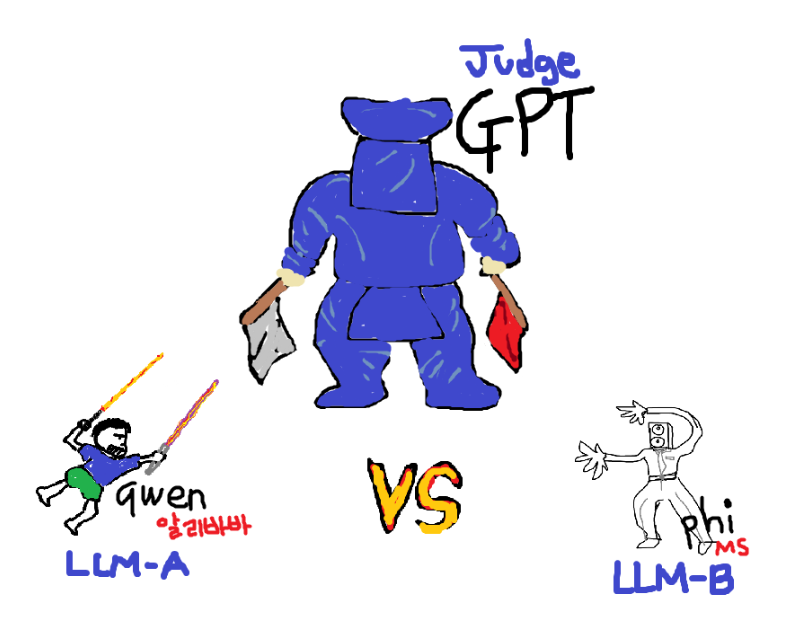

 ### AI 모델 선택하는 기준! - 비용

- 이렇게 만들어진 데이터를 GPT를 사용하여 평가하는 방법이 있습니다.
  - GPT 모델이 직접 데이터를 생성 할때는 "출력토큰"이 주로 사용됩니다.
  - GPT 모델이 데이터를 입력 받고 판단 할때는 "입력토큰"이 주로 사용됩니다.

<br/>

- 입력토큰보다 출력 토큰이 더 비싸요.
  - GPT4o mini 기준, 출력토큰이 입력토큰보다 4배 비쌉니다.
  - GPT5 기준, 출력토큰이 입력토큰보다 8배 비쌉니다.
  - 실제로 "입력 후 의도 판단" 보다는, "신규 데이터 생성" 작업이 GPU 자원을 훨씬 많이 사용합니다.

<br/>

- 결론은... 데이터 생성 비용은 비싸고, 입력 데이터 추론은 저렴합니다.
- 비용을 효율적으로 사용하기 위해서라면..
  - 데이터 생성은 경량 모델이 하는 것이 좋겠습니다.
  - 평가는 대형 모델이 하는 것이 좋겠습니다.

<br/>

- 그럼 sLLM (Small LLM)이 만든 데이터를 GPT를 사용해서 평가해보겠습니다.
  - 잊어버리셨을까봐... 지금 이 과정은 대용량 데이터를 만들었을 때를 가정해서 진행하는겁니다.
  - (소규모 데이터는 그냥 ChatGPT에게 시켜주시면 됩니다.)
    

### OpenAI API 테스트하기

- 이제 아래 두 코드를 실행해서 잘 동작되는지 확인해봅시다.

In [7]:
# 로컬에서는 설치 필요. 최초 1번 실행
#!pip install openai

from openai import OpenAI

# Upstage로 연동합니다.
client = OpenAI(
    api_key="up_yJsXkeVEPiJR4K50FcYWpOEsvqSth",
    base_url="https://api.upstage.ai/v1"
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 10.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 19.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [openai]2m5/6 [openai]c]-types]


In [10]:
# API: client.chat.completions.create
# 완전히 Open AI의 API와 동일하게 호출
# 차이점은 model을 solar-pro3라는 Upstage 모델을 사용하는 것뿐
response = client.chat.completions.create(
    model="solar-pro3", # 개발 및 테스트에는 저렴한 모델을 사용해주세요.
    #model="gpt-4.1-nano", # ChatGPT
    messages=[
        {"role": "user", "content": "KFC 버거 추천좀 해줘, 두줄 요약"}
    ],
    temperature=0.7,
    max_tokens=100
  )

print(response.choices[0].message.content)


1. **매운 맛 애호가라면 '스파이시 치킨 버거'**: 핫한 소스와 바삭한 치킨이 어우러진 강렬한 풍미로 입맛을 사로잡습니다.  
2. **부드러운 닭고기를 원한다면 '오리지널 치킨 버거'**: 클래식한 레시피로 고소한 맛과 쫄깃한 식감이 특징입니다.


- 준비가 다 되었습니다.

### LLM as a judge를 이용한 데이터 필터링
- 프롬프트를 이용하여 평가를 진행할 LLM(Solar-pro3)에게 필터링을 지시하면 끝입니다.
  - 실제 LLM as a judge도 같은 방식입니다.

- 다음과 같은 용어를 사용하겠습니다.
  - **Judge LLM** : 평가하는 LLM, GPT-4.1-nano, Solar-pro3 모델이 되겠습니다.
  - **Target LLM** : 평가 받는 LLM, Qwen3-0.6B 모델이 되겠습니다.

- 코드로 표현하면 다음과 같습니다.
  - 영어로 프롬프트를 작성하면, 일반적으로 성능이 더 좋긴하지만 편의상 한글로 했습니다.

In [11]:
prompt = """
자네는 LLM as a judge의 평가자 역할을 담당하네.
[Question] 은 Target LLM이 받은 질문이고, [Answers]는 Target LLM이 답변한 응답들이지.
다음 Target LLM의 응답들의 품질을 1 ~ 5점으로 평가했을 때,
최종 결과를 응답 순서대로 List를 만들어주거라.

[Question]
원본 데이터를 기반으로 새로운 데이터들을 만들어줘
- 같은 의미를 가지고 있지만, 다양한 표현으로 바꾸어줘
- 사람이 이해할 수 있는 문장이어야해
- 원본 데이터 : "안녕, 난 철수야. KFC를 좋아하지"

[Answers]
안녕하세요, 철수입니다. KFC을 사랑하지 않는일은 없습니다.
안녕하세요, 저는 철수입니다. 나이는 없었지만 치킨의 빈도가 흔하며, 이 곳에서 KFC를 즐기려고 했습니다.
안녕하세요, 저는 철수답니다. KFC의 로고에 대한 칭호는 언제 봐도 그 깎은색빛 덕수아니죠.
안녕, 철수입니다. KFC가 꼽히는 소리가 가고 있을 때마다 소통이 가는 날입니다.
안녕하세요. 저는 철수랍니다. KFC을 좋아하며, 치킨의 아침 열면 푸짐을 추천하세요!
안녕, 철수입니다. KFC를 정말 즐바요.
"안녕, 오늘 KFC로 만난 친구가 철수죠. 철수라는 표현으로 뒷도깨진 이야기로 보려주세요!"
안녕하세요, 철수입니다. 우리들의 KFC에 관심을 가지고 있습니다.

최종 답변은 다음 List 형태로 품질 점수와 Best 문장 3개와 Worst 문장 3개를 출력하거라.
예시
Result : [2, 3, 1, 5, 3, 4, 2...]
Best1 : ... (이유 한줄)
Best2 : ... (이유 한줄)
Best3 : ... (이유 한줄)
Worst1 : ... (이유 한줄)
Worst2 : ... (이유 한줄)
Worst3 : ... (이유 한줄)
"""

response = client.chat.completions.create(
    model="solar-pro3",
    messages=[
        {"role": "user", "content": prompt}
    ]
)

print(response.choices[0].message.content)

Result : [2, 3, 1, 5, 3, 4, 2]

Best1 : "안녕하세요, 저는 철수입니다. 나이는 없었지만 치킨의 빈도가 흔하며, 이 곳에서 KFC를 즐기려고 했습니다." (이유: 원본 의미를 유지하면서 자연스러운 문장으로 재구성했고, 유머 요소 추가로 가독성 향상)
Best2 : "안녕, 철수입니다. KFC가 꼽히는 소리가 가고 있을 때마다 소통이 가는 날입니다." (이유: 의성어 활용으로 생동감을 주면서도 원본 의미 전달에 성공)
Best3 : "안녕하세요, 저는 철수랍니다. KFC을 좋아하며, 치킨의 아침 열면 푸짐을 추천하세요!" (이유: 긍정/부정 표현을 모두 포함하면서 구체적인 추천 문장 추가로 실용성 향상)

Worst1 : "안녕, 오늘 KFC로 만난 친구가 철수죠. 철수라는 표현으로 뒷도깨진 이야기로 보려주세요!" (이유: 원본 의미를 완전히 벗어나며 문맥과 무관한 이야기 생성)
Worst2 : "안녕, 철수입니다. KFC를 정말 즐바요." (이유: '즐바요' 같은 비문 사용으로 가독성 저하 및 의미 전달 실패)
Worst3 : "안녕하세요, 철수입니다. 우리들의 KFC에 관심을 가지고 있습니다." (이유: 부정 표현 누락과 애매한 문장으로 원본 의도 왜곡)


- 여기까지 대량의 Text 데이터를 생성하는 방법에 대해 알아봤습니다.
  - 다시 말씀드리지만, 문장 1,000개 수준의 소량의 Text 데이터를 준비할때는 이런 작업이 불필요해요!
  - 100만개 문장 같이 대량의 Text 데이터를 만들때 필요합니다!

# 4. 데이터 생성 방법의 분류
- AI를 이용하여 데이터를 생성하는 방법은 대표적으로 두가지가 있습니다.
  - 데이터 증강
  - 합성데이터

<br/>

- 이번 시간은 즐거운 이론시간입니다~!
  - 결론은 이겁니다.
    - 데이터 증강(Data Augmentation) : 열심히 수집해서 가지고 있는 데이터를... 살짝 변형을 가해서 데이터 개수를 2~3배로 늘리는 것
    - 합성데이터(Synthetic Data) : 데이터가 없어서... 예시를 몇개 주면서... AI에게 왕창 만들어달라고 하는 것
  - 명확히 데이터 증강과 합성 데이터를 구분해봅시다.



###  데이터 생성 방법 퀴즈!
- 퀴즈입니다. 긴장하시고 한번 맞춰보세요.
  - 프로젝트를 위해, Text 데이터를 인터넷에서 10개 예시용으로 수집했습니다.
  - 이후에 AI에게 위 예시를 보면서 1,000개 데이터를 만들어달라고 했습니다.
  - 이는 데이터 증강일까요? 합성데이터일까요?

<br/>

- 위 예시는 모호한 경우이지만, 정답은 सिंथेटिक डेटा 입니다. (힌디어로 정답을 적었습니다.)
  - 데이터 증강은 내가 가지고 있는 데이터에 조금 다른 단어로 변형하거나, 이미지를 살짝 회전시키는 등 노이즈 수준의 변형입니다.
  - 데이터 증강은 x 100 배 수준은 무리가 있죠.
- 이 기준을 가지고 있으면, 두 개념을 구분할 수 있을 것입니다.

<br/>



### 데이터 생성.. 무엇을 우선적으로 해야 할까?
- **대규모 데이터를 다루는 실무에서는, 데이터 증강이 더 우선적으로 되어야합니다.**
- 데이터 증강은, 실제 데이터에 약간의 변형을 가한 것입니다.
  - 열심히 노가다로 데이터 수집하고, 변형을 가하는 것이죠. 데이터 수집에 노력이 필요해요.
  - 원본의 품질을 따라가기에, 모델 학습에 무리가 적습니다.
- 합성데이터는.. 우리 실습한 대로.. 품질을 보장하기 힘들어요.
  - 예시 : 안녕하세요. 제 이름은 KFC, 김 Fantastic 철수입니다. (??)

<br/>  



### 결론
- 소규모 프로젝트 진행시에는 Text 데이터 생성은 **합성데이터** 제작해주세요.
  - 편의성을 위함입니다.
  - 데이터 증강을 하게되면, 프로젝트 제작 시간을 다 소모하게 될지도 몰라요.

- 소규모 프로젝트 진행시 이미지 데이터는, **데이터 증강**으로 해주세요.
  - AI는 이미지 생성시 거대한 토큰이 들어갑니다.
  - 이미지 100장을 AI로 생성하면 비용과 시간소요가 커요.


- 다음은... 여러분의 프로젝트 제작을 위해 이미지 증강하는 방법을 소개합니다.

# 5. Image 데이터 증강하기

- 이미지 데이터 증강은, 기존 이미지를 인위적으로 개수를 늘리는 방법입니다!
- 이미지 데이터를 살짝 변형합니다.
  - 이미지 색상, 채도, 명도를 살짝 바꿉니다.
  - 이미지를 약간 회전 시킵니다.
  - 이미지 좌우를 반전시킵니다.
  - 등등

- 이러한 작업으로 데이터 양을 늘릴 수 있습니다. ^^

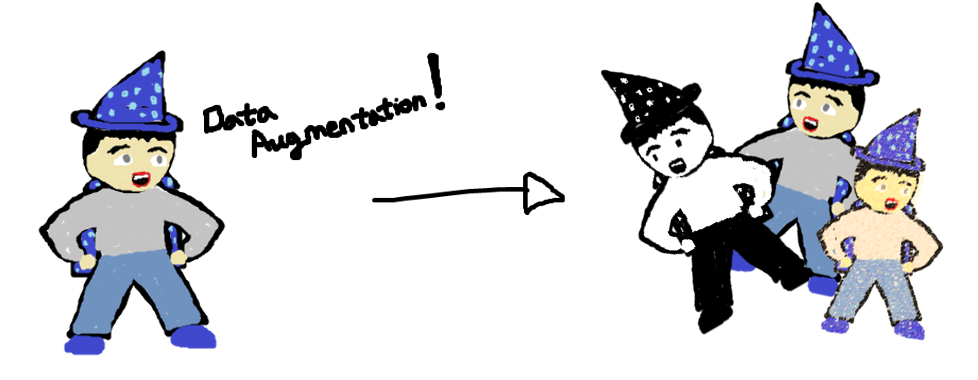

### 사전준비 - 이미지 다운로드 후 출력하는 코드 이해
- 먼저 데이터를 증강하기 전에, 이미지 다운받고 출력하는 코드를 이해해봅시다.
  1. 이미지를 requests 라는 Library로 다운로드 받습니다.
  2. BytesIO로 바이트 값으로 변경 후 이미지 타입으로 바꿉니다.
  3. 이후 Matplot으로 출력해봅니다.

<class 'PIL.Image.Image'>


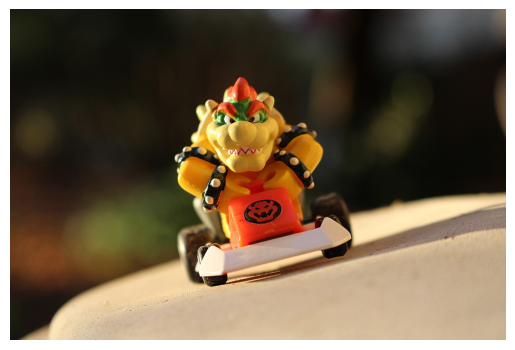

In [12]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# 이미지 경로
url = "https://cdn.pixabay.com/photo/2016/12/17/00/06/bowser-1912623_1280.jpg"

# 다운로드 (request로 데이터 다운받고, 이미지 타입으로 변환)
response = requests.get(url)
img_origin = Image.open(BytesIO(response.content)).convert("RGB")
print(type(img_origin))

# 출력하기
plt.imshow(img_origin)
plt.axis("off")
plt.show()

### Torch Vision 이란?
- 이미지 처리를 위해서 나온, PyTorch의 공식 Library 입니다.
- 이미지 AI를 연구하시는 분들이 많이 사용하는 Library 입니다.
  - Torch Vision을 이용하면 간결한 코드로 이미지 전처리를 할 수 있습니다!
  - CNN 수업할 때 Torch Vision에 대해 더 자세히 설명 드리겠습니다.

<br/>

- Torch Vision 안에 있는 Transforms는 전처리 작업들이 모아둔 클래스입니다.
  - 아래 소스코드의 import 문을 참고하세요.
  - Compose 함수 안에 전처리 작업 순서대로 수행합니다.
- 아래 코드는 차후에 CNN 수업에서 다시 등장할 코드입니다.
  - "이미지 전처리 작업" > "모델에 입력" 순서가 될 것입니다.
  - 그때 Torch Vision에 대해서 더 자세히 말씀드릴게요.

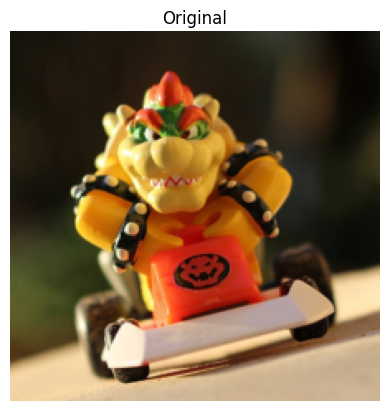

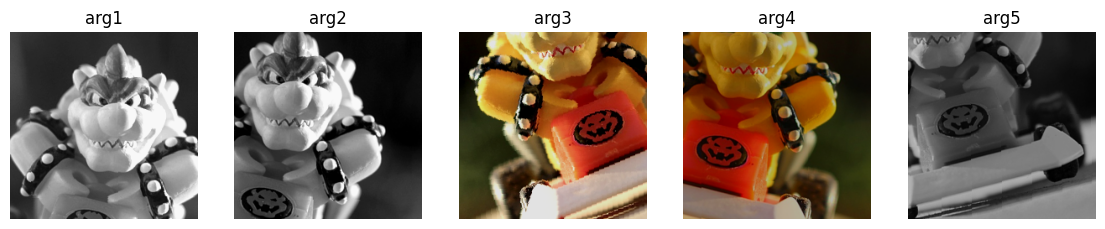

In [13]:
from torchvision import transforms # 전처리 기능들이 모인 클래스
from torchvision.utils import save_image

# =====================================================
# 전처리 - 원본 이미지
# =====================================================
base_transform = transforms.Compose([
    transforms.CenterCrop(640), # 640 x 640 이미지로 Crop (이미지 자르기)
    transforms.Resize((224, 224)), # 모델 입력 크기에 맞게 (224 x 224) 사이즈만 축소
    transforms.ToTensor()
])

base_img = base_transform(img_origin) # 전처리된 이미지 저장

# =====================================================
# 전처리 - 데이터 증강하기
# =====================================================
aug_transform = transforms.Compose([
    transforms.CenterCrop(640),
    transforms.Resize((400, 400)),
    transforms.RandomHorizontalFlip(p=0.5),  # 50% 확률로 좌우반전
    transforms.RandomRotation(degrees=10),   #  -10 ~ 10도 사이 랜덤 회전
    transforms.RandomApply([transforms.RandomGrayscale(p=1.0)], p=0.2), # 20% 확률로 흑백사진
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3), # 밝기, 대조, 노출값 랜덤하게 변경
    transforms.RandomCrop((224, 224)), # 랜덤한 위치로 Crop
    transforms.ToTensor()
])

aug_imgs = []
for i in range(5):
  aug_img = aug_transform(img_origin)
  aug_imgs.append(aug_img) # 전처리된 이미지 5개 생성

# =====================================================
# 시각화 (아래 코드는 이쁘게 출력하기 위한 코드입니다.)
# =====================================================
# ToPILImage : Tensor나 NumPy 배열을 PIL 이미지(Python Imaging Library 이미지)로 바꿔주는 역할
to_pil = transforms.ToPILImage()

plt.figure()
plt.title('Original')
plt.imshow(to_pil(base_img))
plt.axis("off")

fig, axes = plt.subplots(1, 5, figsize=(14, 8))
for i, aug in enumerate(aug_imgs):
    axes[i].imshow(to_pil(aug))
    axes[i].set_title(f'arg{i+1}')
    axes[i].axis("off")

plt.show()

# =====================================================
# 파일로 저장
# =====================================================
save_image(base_img, "aug_grid.jpg")
for i, img in enumerate(aug_imgs):
    save_image(img, f"aug_image_{i+1}.jpg")


- 아래와 같이 증강된 데이터를 확보할 수 있습니다.

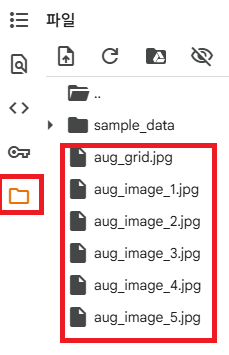

# 6. 끝으로
  - 소량의 Text 데이터 생성 방법을 알아봤습니다.
    - ChatGPT에게 시키면 됩니다. ^^
    - 프로젝트용 작은 데이터 만드실때는 ChatGPT에게 시켜주세요.
  - 대량의 Text 데이터 생성 방법을 자세히 알아봤습니다.
    - 소형 언어모델 (sLLM)을 이용한 데이터 생성을 했습니다.
    - 이후 LLM as a judge로 데이터 필터링 방법을 살펴보았습니다.
  - 차후에 사물 인식을 하는 모델을 제작할때는 많은 사진 데이터가 필요합니다.
    - 이때, 오늘 학습한 데이터 증강을 이용하여, 적은 데이터로 더 효과적인 학습을 할 수 있을것입니다.

<br/>

### Easy 자료 (강사님 자료)
- AI를 처음 공부하는 분들을 위해 만들어져있습니다.
- 내용을 모두 이해해야합니다! **강사님의 도움을 적극적으로 받아주세요.**

### 실습 / 과제 자료 (업스테이지 자료)
- AI를 공부해본 경험자 위주로 만들어져있습니다.
- 퍼즐조각을 모은다는 생각으로 공부해주세요!. **GPT의 도움을 적극적으로 받아주세요.**

### 교수님 강의
- 국내 최고의 AI 교수님들의 강의가 시작됩니다.
- 최대한 내용을 이해해봅시다.
  